In [1]:
%load_ext autoreload
%autoreload 2

## Imports

In [2]:
import ee
import geemap
import matplotlib.pyplot as plt
import pandas as pd
import datetime

In [3]:
try:
    ee.Initialize()
except:
    # need to authenticate with your credential at the first time
    ee.Authenticate()
    ee.Initialize()

## Image Preprocessing Functions, to be moved to module

In [4]:
def maskS2clouds(image):
    qa = image.select('QA60')
    neighbor_size = 30         # 30 pixels or 300 meters
    quality_threshold = 0.05   # above 5% of cloud or shadow would be masked
    
    # Bits 10 and 11 are clouds and cirrus, respectively.
    cloudBitMask = 1 << 10
    cirrusBitMask = 1 << 11
    
    # Both flags should be set to zero, indicating clear conditions.Both flags should be set to zero, indicating clear conditions.
    mask = qa.bitwiseAnd(cloudBitMask).eq(0) \
      .And(qa.bitwiseAnd(cirrusBitMask).eq(0))
    
    """
    *  Account for shadow effect and use neighborhood average
    """
    # calculate the neighborhood average (NA) fraction of cloud (SCL 8-10)
    cldPrbNA = image.select('SCL').gte(8).And(image.select('SCL').lte(10)) \
        .reduceNeighborhood(**{
            'reducer': ee.Reducer.mean(),
            'kernel': ee.Kernel.circle(neighbor_size)
        }).rename('cldPrbNA')
    
    # calculate the neighborhood average (NA) fraction of shadow (SCL 3)
    cldShadowNA = image.select('SCL').eq(3) \
        .reduceNeighborhood(**{
            'reducer': ee.Reducer.mean(),
            'kernel': ee.Kernel.circle(neighbor_size)
        }).rename('cldShadowNA')
    
    # the NA fraction of clouds and shadow
    cldTotalNA = cldPrbNA.add(cldShadowNA)
    
    # Update the mask, cldTotalNA should be lower than quality_threshold defined above
    mask = mask.And(cldTotalNA.lt(quality_threshold))
    return image.updateMask(mask).divide(10_000) \
        .addBands(cldPrbNA).addBands(cldShadowNA) \
        .copyProperties(image, ['system:time_start'])

In [5]:
def addVegetationIndices(image):
    image = image.clip(MtPleasant)
    
    NIRv = image.expression(
        '((NIR - RED) / (NIR + RED)) * NIR',
        { 
          'NIR': image.select('B8'),
          'RED': image.select('B4')
        }).rename('NIRv')
    
    EVI = image.expression(
        '2.5 * ((NIR - RED) / (NIR + 6 * RED + 7.5 * BLUE + 1))',
        {
            'NIR': image.select('B8'),
            'RED': image.select('B4'),
            'BLUE': image.select('B2')
        }).rename('EVI')
    
    # Return the masked image with NIRv and EVI bands.
    return image.addBands(NIRv).addBands(EVI)

## Extracting Time Series Data for a Specific Pixel

In [6]:
# Define study region
MtPleasant = ee.Geometry.Polygon(
    [-76.39092979365925, 42.47111031803205,
     -76.39092979365925, 42.46458902246419,
     -76.37702522212605, 42.46458902246419,
     -76.37702522212605, 42.47111031803205], None, False)

# Setup Sentinel-2 image collection over study region with low(ish) cloud cover
site_images = ee.ImageCollection("COPERNICUS/S2_SR") \
    .filterBounds(MtPleasant) \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 80)) \
    .map(maskS2clouds).map(addVegetationIndices)

In [7]:
Map = geemap.Map()
rgbVis = {
  'bands': ['B4', 'B3', 'B2'],
  'min': 0,
  'max': 0.2,
}
Map.addLayer(site_images.mosaic(), rgbVis, 'Sentinel-2 Image')
Map.centerObject(MtPleasant)
display(Map)

Map(center=[20, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=HBox(children=(Togg…

In [8]:
# Paramters for analysis
coords = [-76.3892, 42.4693]
poi = ee.Geometry.Point(coords)
band = 'EVI'

# Reduces region of image using median, then returns a feature with the index and median value
def extract_data(image):
        stats = image.reduceRegion(
            reducer = ee.Reducer.median(),
            geometry = poi,
            scale = 10,
            #bestEffort = True,
            crs = 'EPSG:4326'
        )
        properties = {
            'system_index': image.get('system:index'),
            band: stats.get(band)
        }
        return ee.Feature(None, properties)
    
data = ee.FeatureCollection(site_images.map(extract_data))
df = geemap.ee_to_pandas(data, ['system_index', band]).dropna()

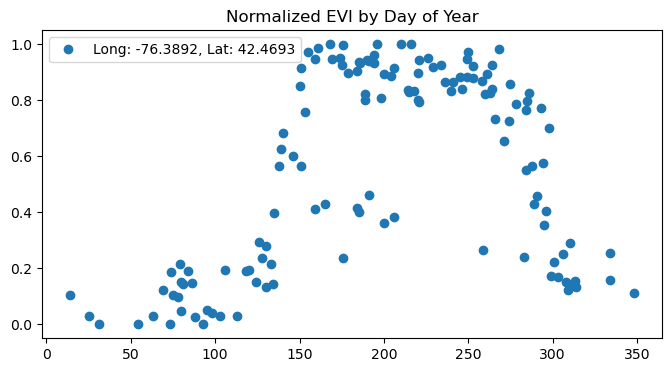

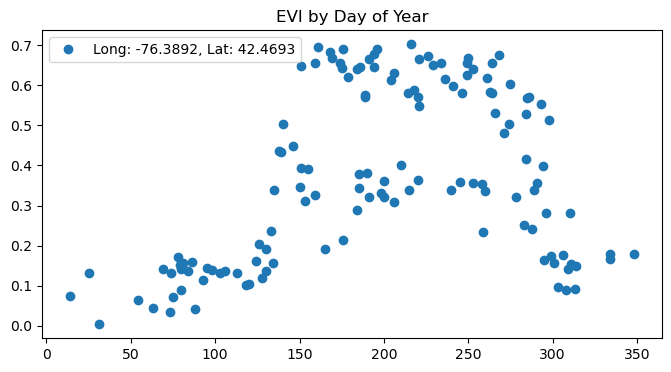

In [9]:
# Plot EVI of poi by day of year
# TODO: Normalize data by year

def convert_index_to_date(index):
    return datetime.date(year = int(index[0:4]),
                         month = int(index[4:6]),
                         day = int(index[6:8]))
                


df['Date'] = df['system_index'].map(convert_index_to_date)
df['Year'] = df['Date'].map(lambda x: x.year)
df['doy'] = df['Date'].map(lambda x: x.timetuple().tm_yday)

df['EVI_nrml'] = df.groupby(['Year']).transform(lambda x: (x - x.min())/(x.max() - x.min()))['EVI']


plt.figure(figsize = (8, 4))
plt.plot(df['doy'], df['EVI_nrml'], 'o', label=f'Long: {coords[0]}, Lat: {coords[1]}')
plt.legend()
plt.title('Normalized EVI by Day of Year')
plt.show()

plt.figure(figsize = (8, 4))
plt.plot(df['doy'], df['EVI'], 'o', label=f'Long: {coords[0]}, Lat: {coords[1]}')
plt.legend()
plt.title('EVI by Day of Year')
plt.show()

## Fit a Generalized Additive Model (GAM) to our data

In [10]:
# Use a GAM with a Normal Distribution and an identity link function
from pygam import LinearGAM, s

X = df['doy']
y = df['EVI_nrml']

gam = LinearGAM(s(0, n_splines = 20)).fit(X, y)

ModuleNotFoundError: No module named 'pygam'

In [ ]:
import os 
import inspect 
print(os.path.dirname(inspect.getfile(inspect))+"/site-packages") 

In [ ]:
X_grid = gam.generate_X_grid(0)
y_pred = gam.predict(X_grid)

plt.plot(X, y, 'o', color='grey')
plt.plot(X_grid, y_pred)
plt.show()

Due to a few measurements with relatively low EVI in the late-spring/early-summer time period (150-225), this model does not appear to fully capture seasonal trends. Instead, use an expectile gam to weight the main trend more heavily.

In [ ]:
from pygam import ExpectileGAM

exp_gam = ExpectileGAM(s(0, n_splines = 25) + s(0), expectile=0.90).fit(X,y)

In [ ]:
X_grid_exp = exp_gam.generate_X_grid(0, n=1000)
y_pred_exp = exp_gam.predict(X_grid_exp)

plt.plot(X, y, 'o', color='grey')
plt.plot(X_grid_exp, y_pred_exp)
plt.show()

In [ ]:
import ruptures as rpt

In [ ]:
algo = rpt.Window(model="clinear", width=300).fit(y_pred_exp)
my_bkps = algo.predict(n_bkps = 3)

In [ ]:
rpt.show.display(y_pred_exp, bkps, my_bkps, figsize=(10, 6))
plt.show()

In [ ]:
my_bkps_doy = [((348 - 14) * x) / 1000 + 14 for x in my_bkps] #x_grid onlycovers 14 to 348

In [ ]:
X_grid_exp = exp_gam.generate_X_grid(0, n=1000)
y_pred_exp = exp_gam.predict(X_grid_exp)

plt.figure(figsize=(6,4))
plt.plot(X, y, 'o', color='grey')
plt.plot(X_grid_exp, y_pred_exp)
for bkp in my_bkps_doy:
    plt.axvline(x = bkp, color = 'b', label = 'axvline - full height', linestyle='dashed')
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression

reg1 = LinearRegression().fit(X_grid_exp[:my_bkps[0]], y_pred_exp[:my_bkps[0]])
y_lin_1 = reg1.predict(X_grid_exp[:my_bkps[0]])

reg2 = LinearRegression().fit(X_grid_exp[my_bkps[0]:my_bkps[1]], y_pred_exp[my_bkps[0]:my_bkps[1]])
y_lin_2 = reg2.predict(X_grid_exp[my_bkps[0]:my_bkps[1]])

reg3 = LinearRegression().fit(X_grid_exp[my_bkps[1]:my_bkps[2]], y_pred_exp[my_bkps[1]:my_bkps[2]])
y_lin_3 = reg3.predict(X_grid_exp[my_bkps[1]:my_bkps[2]])

reg4 = LinearRegression().fit(X_grid_exp[my_bkps[2]:], y_pred_exp[my_bkps[2]:])
y_lin_4 = reg4.predict(X_grid_exp[my_bkps[2]:])


In [ ]:
X_grid_exp = exp_gam.generate_X_grid(0, n=1000)
y_pred_exp = exp_gam.predict(X_grid_exp)

plt.figure(figsize=(6,4))
plt.plot(X, y, 'o', color='grey')
plt.plot(X_grid_exp, y_pred_exp)
for bkp in my_bkps_doy:
    plt.axvline(x = bkp, color = 'b', label = 'axvline - full height', linestyle='dashed')
plt.plot(X_grid_exp[:my_bkps[0]], y_lin_1)
plt.plot(X_grid_exp[my_bkps[0]:my_bkps[1]], y_lin_2)
plt.plot(X_grid_exp[my_bkps[1]:my_bkps[2]], y_lin_3)
plt.plot(X_grid_exp[my_bkps[2]:], y_lin_4)
plt.show()

In [ ]:
df['Pred_EVI_nrml'] = exp_gam.predict(df['doy'])
df['Anom_EVI_nrml'] = df['EVI_nrml'] - df['Pred_EVI_nrml']

In [ ]:
colors = {2016:'tab:blue', 2017:'tab:orange', 2018:'tab:green', 2019:'tab:red', 2020:'tab:purple', 2021:'tab:brown', 2022:'tab:pink'}
plt.scatter(df[df['Year'] == 2020]['doy'], df[df['Year'] == 2020]['Anom_EVI_nrml'], c = df[df['Year'] == 2020]['Year'].map(colors))
plt.show()

## Hyperparameter tuning for GAM model using Scikit-learn's GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV
import numpy as np

X = df['doy']
y = df['EVI_nrml']

exp_gam = ExpectileGAM(max_iter=1000)

params = {
    'n_splines': [x for x in range(5, 30, 5)],
    'lam': np.logspace(-3, 3, 11),
    'expectile': [0.80, 0.85, 0.90, 0.95]
}

gs_exp_gam = GridSearchCV(exp_gam,
                          param_grid = params,
                          scoring = 'neg_root_mean_squared_error',
                          cv = 5)
gs_exp_gam.fit(X, y)

In [ ]:
X_grid = np.linspace(0, 365, 365)
y_pred = gs_exp_gam.predict(X_grid)

plt.plot(df['doy'], df['EVI_nrml'], 'o')
plt.plot(X_grid, y_pred)
plt.show()

In [ ]:
test_gam = ExpectileGAM(expectile=0.8, lam=0.001, n_splines=5, max_iter=1000)
test_gam.fit(X, y)

y_pred2 = test_gam.predict(X_grid)
plt.plot(df['doy'], df['EVI_nrml'], 'o')
plt.plot(X_grid, y_pred2)
plt.show()

In [ ]:
test_gam2 = ExpectileGAM(expectile=0.8, lam=1, n_splines=100, max_iter=1000)
test_gam2.fit(X, y)

y_pred3 = test_gam.predict(X_grid)
plt.plot(df['doy'], df['EVI_nrml'], 'o')
plt.plot(X_grid, y_pred3)
plt.show()

In [ ]:
import random

def test_exp_gam(X, y, expectile, lam, n_splines):
    gam = ExpectileGAM(expectile = expectile, lam = lam, n_splines = n_splines, max_iter = 1000)
    gam.fit(X, y)
    
    y_pred = gam.predict(X)
    
    return (((y_pred - y)**2).mean())**(0.5)

def cross_validate(X, y, expectile, lam, n_splines, cv, seed=10):
    random.seed(seed)
    orders = list(range(len(X)))
    random.shuffle(orders)  
    n_valid = len(X)//cv
    
    rmse = []
    for i in range(1, cv+1):
        validation_idx = orders[(cv-1)*n_valid:cv*n_valid]
        training_idx = [x for x in range(len(X)) if x not in validation_idx]
                            
        training_X = X.iloc[training_idx]
        training_y = y.iloc[training_idx]
        validation_X = X.iloc[validation_idx]
        validation_y = y.iloc[validation_idx]
                            
        gam = ExpectileGAM(expectile = expectile, lam = lam, n_splines = n_splines, max_iter = 1000)
        gam.fit(training_X, training_y)
        
        y_pred = gam.predict(validation_X)
        rmse.append((((y_pred - validation_y)**2).mean())**(0.5))

    return sum(rmse)/len(rmse)
                            
                            
print(cross_validate(X, y, 0.85, 10, 5, 5, 100))

In [ ]:
expectile_grid = [0.8, 0.85, 0.9, 0.95]
lam_grid = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
n_splines_grid = [5, 10, 15, 20, 25, 30]

results = []
for e in expectile_grid:
    for l in lam_grid:
        for n in n_splines_grid:
            rmse = cross_validate(X, y, e, l, n, 5, 8937568)
            results.append({'expectile':e,
                            'lam':l,
                            'n_splines':n,
                            'rmse':rmse})

results.sort(key = (lambda x: x['rmse']))
results[0]

In [ ]:
best_gam = ExpectileGAM(expectile = results[0]['expectile'],
                        lam = results[0]['lam'],
                        n_splines = results[0]['n_splines'],
                        max_iter = 1000)

best_gam.fit(X, y)
X_grid = np.linspace(0, 365, 365)
y_pred = best_gam.predict(X_grid)

plt.plot(X, y, 'o')
plt.plot(X_grid, y_pred)
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


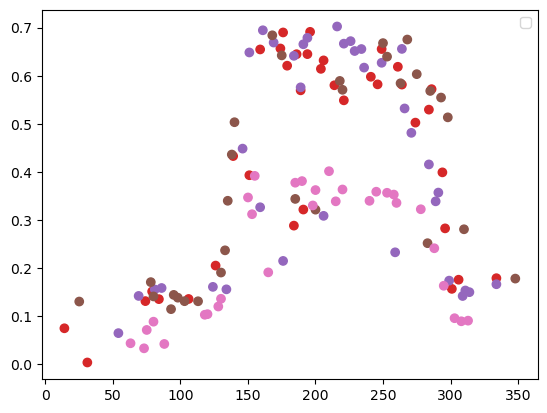

In [11]:
#df['Pred_EVI_nrml'] = best_gam.predict(df['doy'])
#df['Anom_EVI_nrml'] = df['EVI_nrml'] - df['Pred_EVI_nrml']

colors = {2016:'tab:blue', 2017:'tab:orange', 2018:'tab:green', 2019:'tab:red', 2020:'tab:purple', 2021:'tab:brown', 2022:'tab:pink'}
plt.scatter(df['doy'], df['EVI'], c = df['Year'].map(colors))
plt.legend()
plt.show()